In [1]:
%load_ext autoreload
%autoreload 2
from nilearn import plotting


import nilearn as nl
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
from pathlib import Path

from anise.io.load_matlab_dataset import load_data, load_selected_data



Resources:

**I/O**
https://nilearn.github.io/dev/manipulating_images/input_output.html#extracting-data

**Computing ROIs:** 
https://nilearn.github.io/dev/auto_examples/06_manipulating_images/plot_roi_extraction.html#sphx-glr-auto-examples-06-manipulating-images-plot-roi-extraction-py

In [ ]:
Resources

In [44]:
# data_path=Path("/Users/taflalo/Data/PythonfUSITest/BFLY_DIL_EXP2")
# fUSI_data, experiment_timing = load_data(data_path)
# power_doppler_imgs = [data['power_doppler_img'] for data in fUSI_data]

data_path=Path("/Users/taflalo/Data/PythonfUSITest/BFLY_DIL_EXP2")
fUSI_data, experiment_timing,file_list =  load_selected_data(data_path,[0, 1, 2, 10])
power_doppler_imgs = [data['power_doppler_img'] for data in fUSI_data]
# Reordering and replicating the power doppler images to fit MRI standards
power_doppler_imgs=np.array(power_doppler_imgs)
print(power_doppler_imgs.shape)
print(file_list)




(4, 333, 362)
['power_dopplerW_1.mat', 'power_dopplerW_2.mat', 'power_dopplerW_3.mat', 'power_dopplerW_11.mat']
(4, 333, 362)
(362, 2, 333, 4)


In [ ]:
# Current shape of power_doppler_imgs is:
# (time, X, Y) = (time, Superior to Inferior , Left to Right)
# We want to reorder to 
#  = (Left to Right, Posterior to Anterior, Inferior to Superior, Time)
# Since we don't have a Posterior to Anterior dimension, we will replicate the single slice N times along this axis

# Flip the second dimension (Y axis) of each power doppler image
power_doppler_imgs = [np.flip(img, axis=0) for img in power_doppler_imgs]


# First, convert the list of 2D images into a 3D numpy array (time, X, Y)
pd_imgs_3d = np.stack(power_doppler_imgs, axis=0)
print(pd_imgs_3d.shape)

# We need to transpose the array to reorder the dimensions
# Current order is (time, X, Y), we want (Y, Z, X, time), where Z is the new axis to be replicated
pd_imgs_reordered = np.transpose(pd_imgs_3d, (2, 1,0))  # This changes the order to (Y, time, X)

# Now, we replicate the single slice N times along the new Z axis (Posterior to Anterior)
# Let's assume N=10 for demonstration purposes
N = 2
pd_imgs_expanded = np.repeat(pd_imgs_reordered[:, np.newaxis, :, :], N, axis=1)  # This adds and replicates along the new Z axis

print(pd_imgs_expanded.shape)



In [ ]:
def reformat_data(data, input_dims=['T', 'X', 'Y'], output_dims=['X', 'Y', 'Z', 'T'], replicate_dim_N=2):
    """
    Reformat and reorder data based on input and output dimensions.
    
    Parameters:
    - data: numpy array, the data to be reformatted.
    - input_dims: tuple of str, the dimensions labels of the input data (e.g., ('time', 'X', 'Y')). 
                  A negative sign in front of a label (e.g., '-Y') indicates that dimension should be flipped.
    - output_dims: tuple of str, the desired output dimensions ordering (e.g., ('X', 'Y', 'Z', 'T')).
    - replicate_dim_N: int, the number of times to replicate the data along the new axis for dimensions that don't exist in the input.
    
    Returns:
    - reformatted_data: numpy array, the data reformatted to the desired dimensions.
    """
    # Initial checks and setup
    if not isinstance(data, np.ndarray):
        raise ValueError("Data must be a numpy array.")
    if len(input_dims) != data.ndim:
        raise ValueError("Input dimensions must match the number of dimensions in the data.")
    
    # Identify dimensions to flip based on negative sign in input_dims
    input_dims = list(input_dims)  # Convert to list for modification
    for i, dim in enumerate(input_dims):
        if str(dim).startswith('-'):
            data = np.flip(data, axis=i)
            input_dims[i] = dim[1:]  # Remove negative sign after flipping
    
    # Reorder data based on input_dims to output_dims mapping
    dim_order = [input_dims.index(dim) if dim in input_dims else 'replicate' for dim in output_dims]
    reordered_data = np.transpose(data, [dim for dim in dim_order if dim != 'replicate'])
    
    # Handle replication for dimensions that don't exist in the input
    for i, dim in enumerate(dim_order):
        if dim == 'replicate':
            # Add a new axis and replicate along it
            reordered_data = np.expand_dims(reordered_data, axis=i)
            reordered_data = np.repeat(reordered_data, replicate_dim_N, axis=i)
    
    return reordered_data

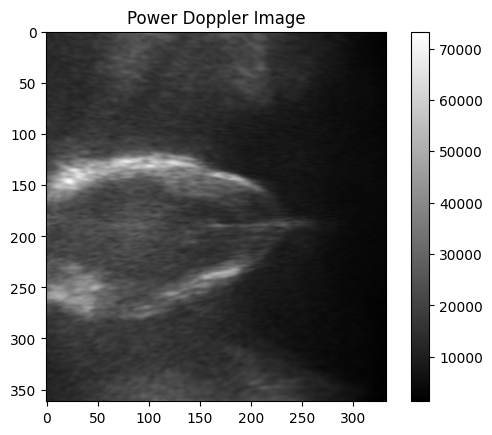

In [45]:


plt.imshow(pd_imgs_expanded[:,0,:,0], cmap='gray')
plt.title('Power Doppler Image')
plt.colorbar()
plt.show()

In [46]:
pd=np.array(power_doppler_imgs)
pd.shape

(4, 333, 362)

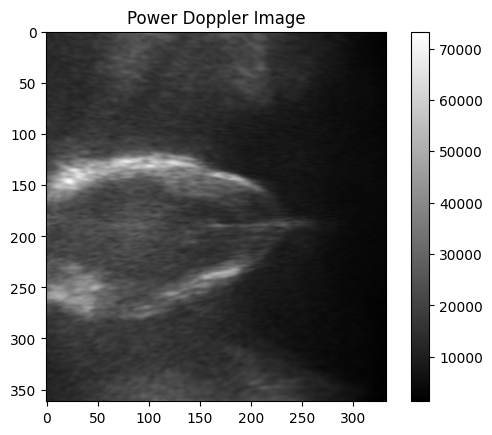

In [47]:

pd=np.array(pd_imgs_expanded[:,:,:,0])
plt.imshow(pd[:,0,:], cmap='gray')
plt.title('Power Doppler Image')
plt.colorbar()
plt.show()




In [60]:
affine=np.diag([.15,.15,.15,1])
nifti_img = nib.Nifti1Image(pd, affine)


In [61]:

nifti_img.to_filename(data_path/"sub-xx_task-label_bold.nii.gz")


In [64]:
from nilearn import image

tmp=image.load_img(data_path/"sub-xx_task-label_bold.nii.gz")


tmp.shape

tmp2=image.smooth_img(tmp,fwhm=1)


In [51]:
tmp2.shape

(362, 2, 333)

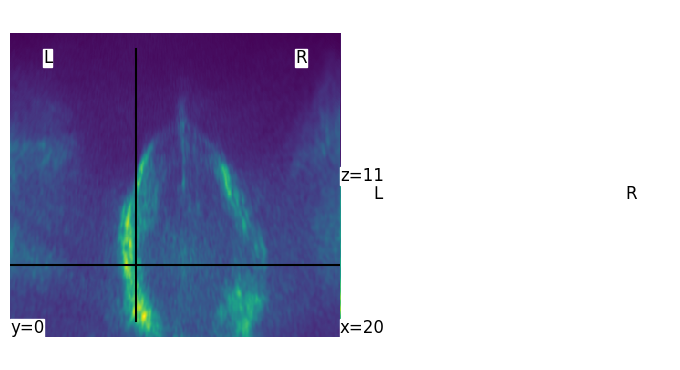

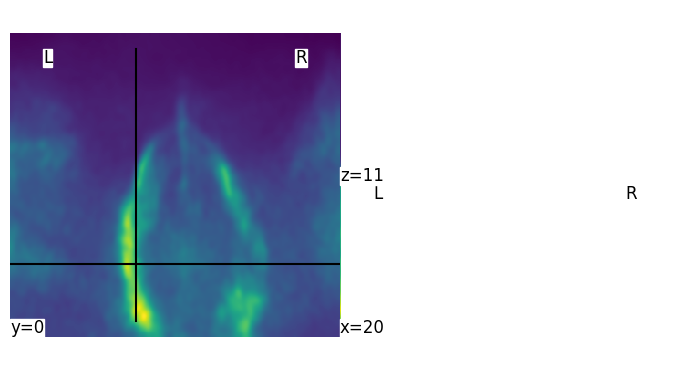

In [65]:
plotting.plot_img(tmp)
plotting.plot_img(tmp2)